In [2]:
import os
import shutil
import random
import pandas as pd

In [3]:
dataset_path = '../dataset'

In [4]:
dataset_name = dataset_path.split('_')[0]
print('数据集', dataset_name)

数据集 ../dataset


In [5]:
classes = os.listdir(dataset_path)

In [6]:
len(classes)

5

In [11]:
classes = ['Blackspot', 'canker', 'greening', 'healthy', 'melanose']

In [13]:
# 创建 train 文件夹
os.mkdir(os.path.join(dataset_path, 'train'))

# 创建 test 文件夹
os.mkdir(os.path.join(dataset_path, 'val'))

# 在 train 和 test 文件夹中创建各类别子文件夹
for fruit in classes:
    os.mkdir(os.path.join(dataset_path, 'train', fruit))
    os.mkdir(os.path.join(dataset_path, 'val', fruit))

FileExistsError: [Errno 17] File exists: '../dataset/../dataset/train'

In [14]:
test_frac = 0.2  # 测试集比例
random.seed(123) # 随机数种子，便于复现

In [15]:
df = pd.DataFrame()

print('{:^18} {:^18} {:^18}'.format('类别', '训练集数据个数', '测试集数据个数'))

for fruit in classes: # 遍历每个类别

    # 读取该类别的所有图像文件名
    old_dir = os.path.join(dataset_path, fruit)
    images_filename = os.listdir(old_dir)
    random.shuffle(images_filename) # 随机打乱

    # 划分训练集和测试集
    testset_numer = int(len(images_filename) * test_frac) # 测试集图像个数
    testset_images = images_filename[:testset_numer]      # 获取拟移动至 test 目录的测试集图像文件名
    testset_images = images_filename[:testset_numer]      # 获取拟移动至 test 目录的测试集图像文件名
    trainset_images = images_filename[testset_numer:]     # 获取拟移动至 train 目录的训练集图像文件名

    # 移动图像至 test 目录
    for image in testset_images:
        old_img_path = os.path.join(dataset_path, fruit, image)         # 获取原始文件路径
        new_test_path = os.path.join(dataset_path, 'val', fruit, image) # 获取 test 目录的新文件路径
        shutil.move(old_img_path, new_test_path) # 移动文件
 # 移动图像至 train 目录
    for image in trainset_images:
        old_img_path = os.path.join(dataset_path, fruit, image)           # 获取原始文件路径
        new_train_path = os.path.join(dataset_path, 'train', fruit, image) # 获取 train 目录的新文件路径
        shutil.move(old_img_path, new_train_path) # 移动文件

    # 删除旧文件夹
    assert len(os.listdir(old_dir)) == 0 # 确保旧文件夹中的所有图像都被移动走
    shutil.rmtree(old_dir) # 删除文件夹

    # 工整地输出每一类别的数据个数
    print('{:^18} {:^18} {:^18}'.format(fruit, len(trainset_images), len(testset_images)))

    # 保存到表格中
    df = df.append({'class':fruit, 'trainset':len(trainset_images), 'testset':len(testset_images)}, ignore_index=True)

# 重命名数据集文件夹
shutil.move(dataset_path, dataset_name+'_split')

# 数据集各类别数量统计表格，导出为 csv 文件
df['total'] = df['trainset'] + df['testset']
df.to_csv('数据量统计.csv', index=False)

SystemError: ../numpy/_core/src/multiarray/iterators.c:192: bad argument to internal function

In [16]:
df

NameError: name 'df' is not defined

In [17]:
!tree dataset -L 2

zsh:1: command not found: tree


In [18]:
!sudo snap install tree


Password:
sudo: a password is required


In [19]:
!tree dataset -L 2

zsh:1: command not found: tree


In [ ]:
import os
import cv2
import pandas as pd
import numpy as np

import torch

import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device', device)

In [ ]:
from torchvision import models
# 载入预训练图像分类模型
model = models.resnet18(pretrained=True)
# model = models.resnet152(pretrained=True)
model = model.eval()
model = model.to(device)
from torchvision import transforms

# 测试集图像预处理-RCTN：缩放裁剪、转 Tensor、归一化
test_transform = transforms.Compose([transforms.Resize(256),
                                     transforms.CenterCrop(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(
                                         mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])
                                    ])

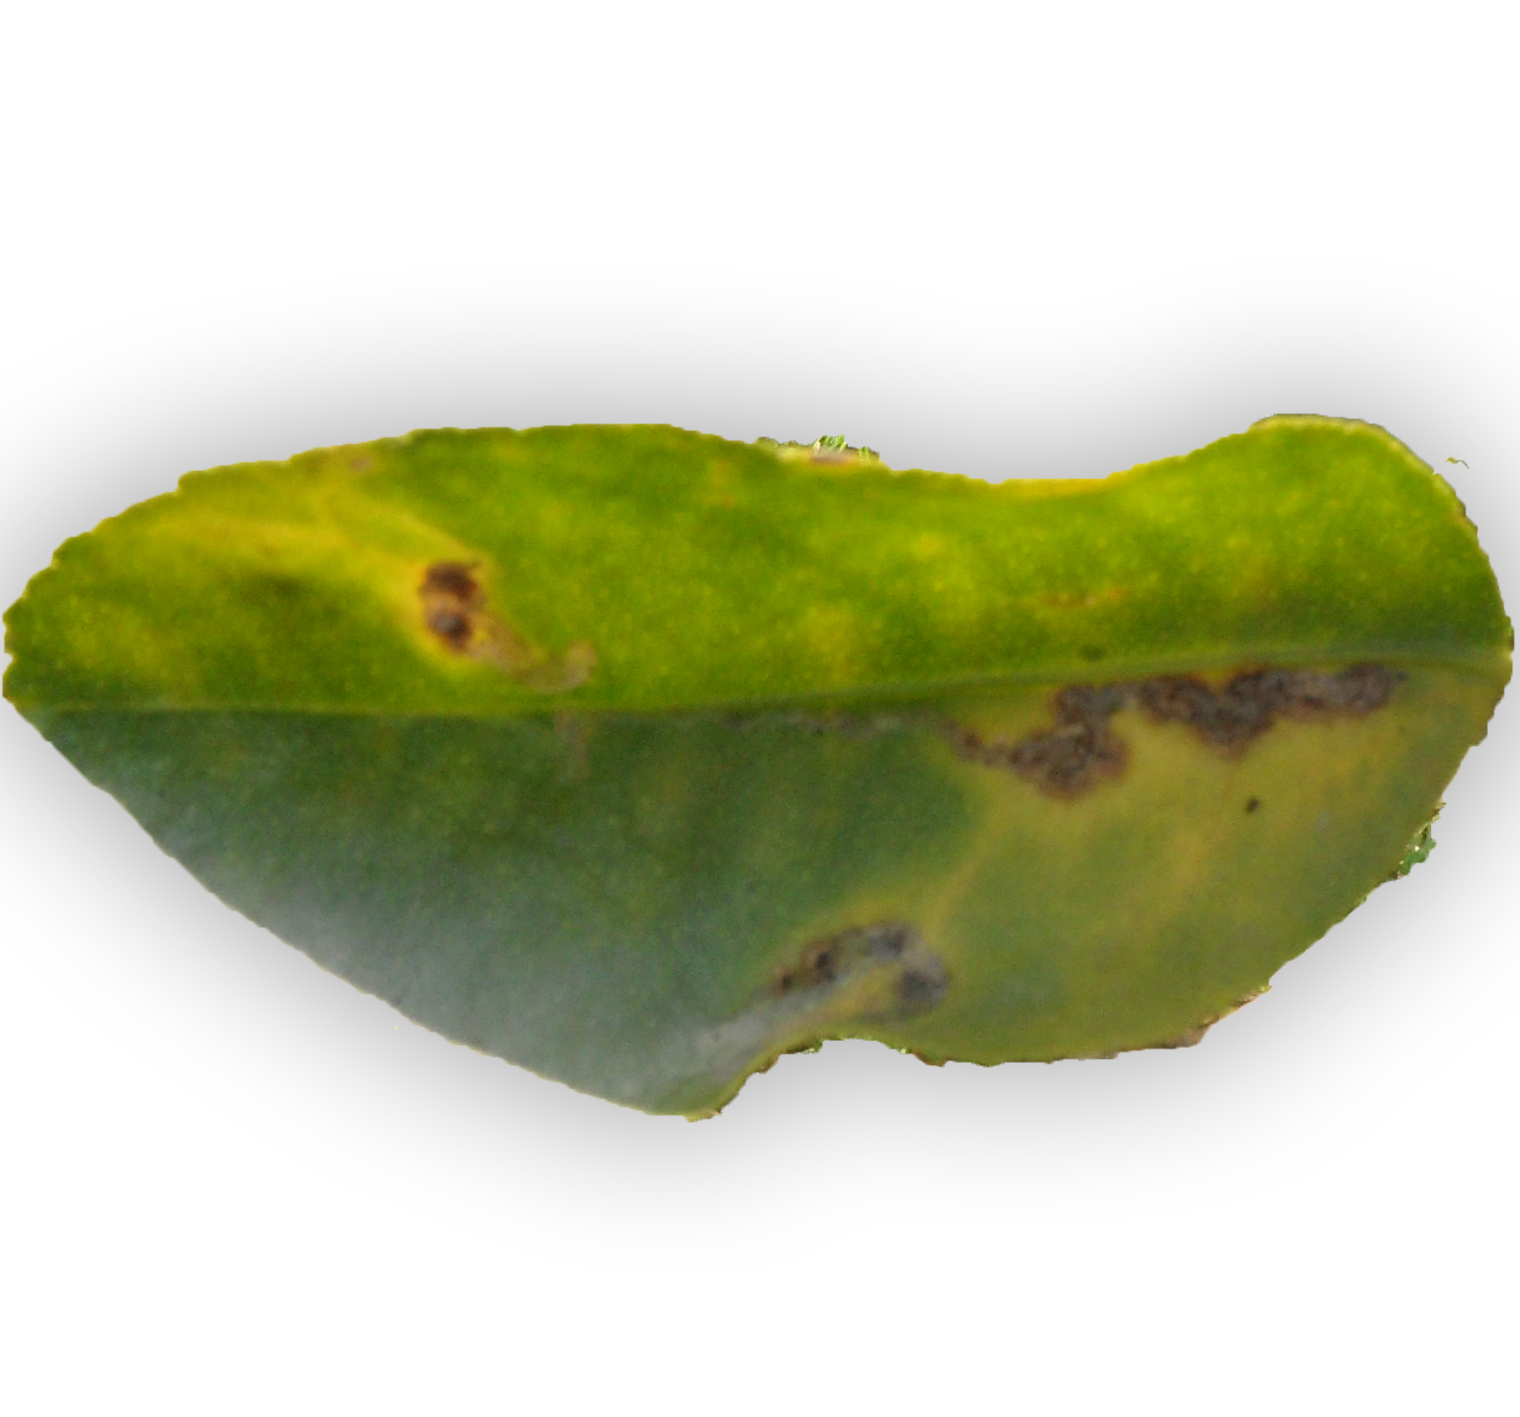

In [20]:
img_path = '../dataset/train/Blackspot/74.jpg'
# 用 pillow 载入
from PIL import Image
img_pil = Image.open(img_path)
img_pil

In [5]:
import os
import cv2
import pandas as pd
import numpy as np
import torch

import matplotlib.pyplot as plt
%matplotlib inline
from torchvision import models
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device', device)
# 载入预训练图像分类模型
model = models.resnet18(pretrained=True)
# model = models.resnet152(pretrained=True)
model = model.eval()
model = model.to(device)
from torchvision import transforms

# 测试集图像预处理-RCTN：缩放裁剪、转 Tensor、归一化
test_transform = transforms.Compose([transforms.Resize(256),
                                     transforms.CenterCrop(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(
                                         mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])
                                    ])
img_path = '../dataset/train/Blackspot/74.jpg'
# 用 pillow 载入
from PIL import Image
img_pil = Image.open(img_path)
np.array(img_pil).shape
input_img = test_transform(img_pil) # 预处理
input_img.shape
input_img = input_img.unsqueeze(0).to(device)
input_img.shape
# 执行前向预测，得到所有类别的 logit 预测
# 分数
pred_logits = model(input_img)
pred_logits.shape
import torch.nn.functional as F
pred_softmax = F.softmax(pred_logits, dim=1) # 对 logit 分数做 softmax 运算
pred_softmax.shape


device cpu


TypeError: expected np.ndarray (got numpy.ndarray)

In [6]:
plt.figure(figsize=(8,4))

x = range(1000)
y = pred_softmax.cpu().detach().numpy()[0]

ax = plt.bar(x, y, alpha=0.5, width=0.3, color='yellow', edgecolor='red', lw=3)
plt.ylim([0, 1.0]) # y轴取值范围
# plt.bar_label(ax, fmt='%.2f', fontsize=15) # 置信度数值

plt.xlabel('Class', fontsize=20)
plt.ylabel('Confidence', fontsize=20)
plt.tick_params(labelsize=16) # 坐标文字大小
plt.title(img_path, fontsize=25)

plt.show()

NameError: name 'pred_softmax' is not defined

Error in callback <function _draw_all_if_interactive at 0x1582dcca0> (for post_execute):


ValueError: object __array__ method not producing an array

<Figure size 800x400 with 0 Axes>

In [2]:
import time
import os
from tqdm import tqdm

import pandas as pd
import numpy as np

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

# 忽略烦人的红色提示
import warnings
warnings.filterwarnings("ignore")

# 获取计算硬件
# 有 GPU 就用 GPU，没有就用 CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device', device)

device cpu


In [2]:
from torchvision import transforms

# 训练集图像预处理：缩放裁剪、图像增强、转 Tensor、归一化
train_transform = transforms.Compose([transforms.RandomResizedCrop(224),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                     ])

# 测试集图像预处理-RCTN：缩放、裁剪、转 Tensor、归一化
test_transform = transforms.Compose([transforms.Resize(256),
                                     transforms.CenterCrop(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(
                                         mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])
                                    ])

In [3]:
#载入图像分类
# 数据集文件夹路径
dataset_dir = '../dataset'
train_path = os.path.join(dataset_dir, 'train')
test_path = os.path.join(dataset_dir, 'val')
print('训练集路径', train_path)
print('测试集路径', test_path)

from torchvision import datasets
# 载入训练集
train_dataset = datasets.ImageFolder(train_path, train_transform)
# 载入测试集
test_dataset = datasets.ImageFolder(test_path, test_transform)

print('训练集图像数量', len(train_dataset))
print('类别个数', len(train_dataset.classes))
print('各类别名称', train_dataset.classes)
print('测试集图像数量', len(test_dataset))
print('类别个数', len(test_dataset.classes))
print('各类别名称', test_dataset.classes)

训练集路径 ../dataset/train
测试集路径 ../dataset/val


NameError: name 'train_transform' is not defined

In [4]:
# 各类别名称
class_names = train_dataset.classes
n_class = len(class_names)
# 映射关系：类别 到 索引号
train_dataset.class_to_idx
# 映射关系：索引号 到 类别
idx_to_labels = {y:x for x,y in train_dataset.class_to_idx.items()}
idx_to_labels

NameError: name 'train_dataset' is not defined

In [6]:
# 保存为本地的 npy 文件
np.save('idx_to_labels.npy', idx_to_labels)
np.save('labels_to_idx.npy', train_dataset.class_to_idx)

In [1]:
idx_to_labels = np.load('idx_to_labels.npy', allow_pickle=True).item()


NameError: name 'np' is not defined